In [3]:
import os

os.chdir('/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC')
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd
import scripts.phot_toolkits as phot_tk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.io import ascii
from astropy.stats import knuth_bin_width
from pathlib import Path
import csv

JWST_files = phot_tk.Pipeline_level_2_data(working_directory = "/net/vdesk/data2/slagter/JWST_NIRCAM_#1227_level_2/mastDownload/JWST")
%load_ext autoreload
%autoreload 2




The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    
Initialized data in ['F187N', 'F115W', 'F444W']


Running for F115W...
    (3) Running starbug
Skipping starbug2 run
Plotting Level 2 downloaded data...
/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC


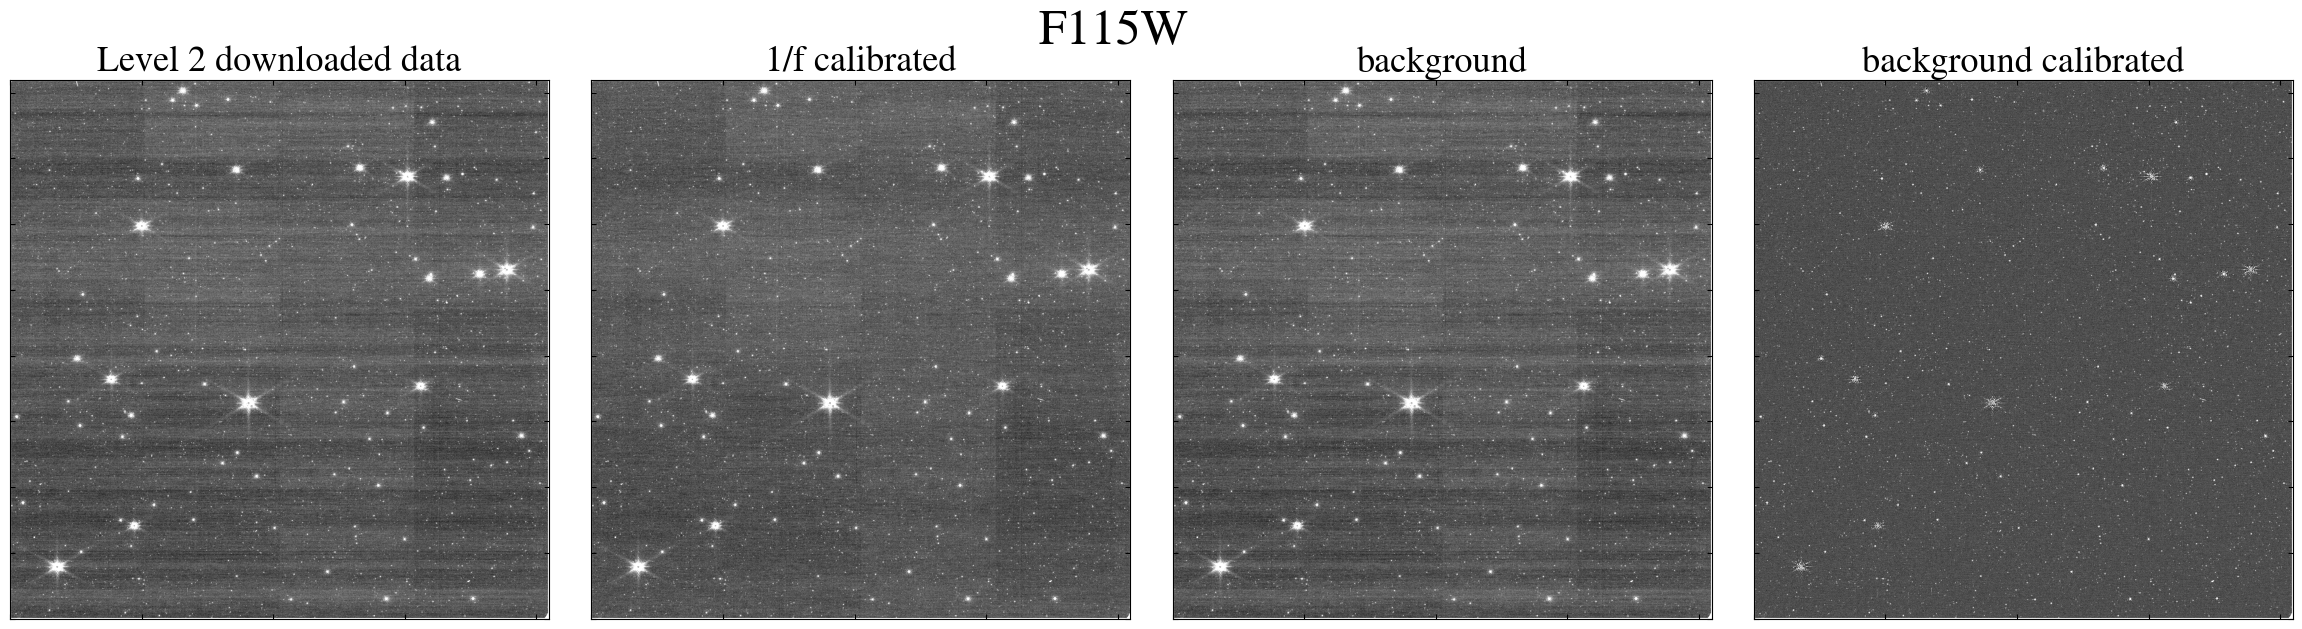

Running for F187N...
    (3) Running starbug
Skipping starbug2 run
Plotting Level 2 downloaded data...
/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC


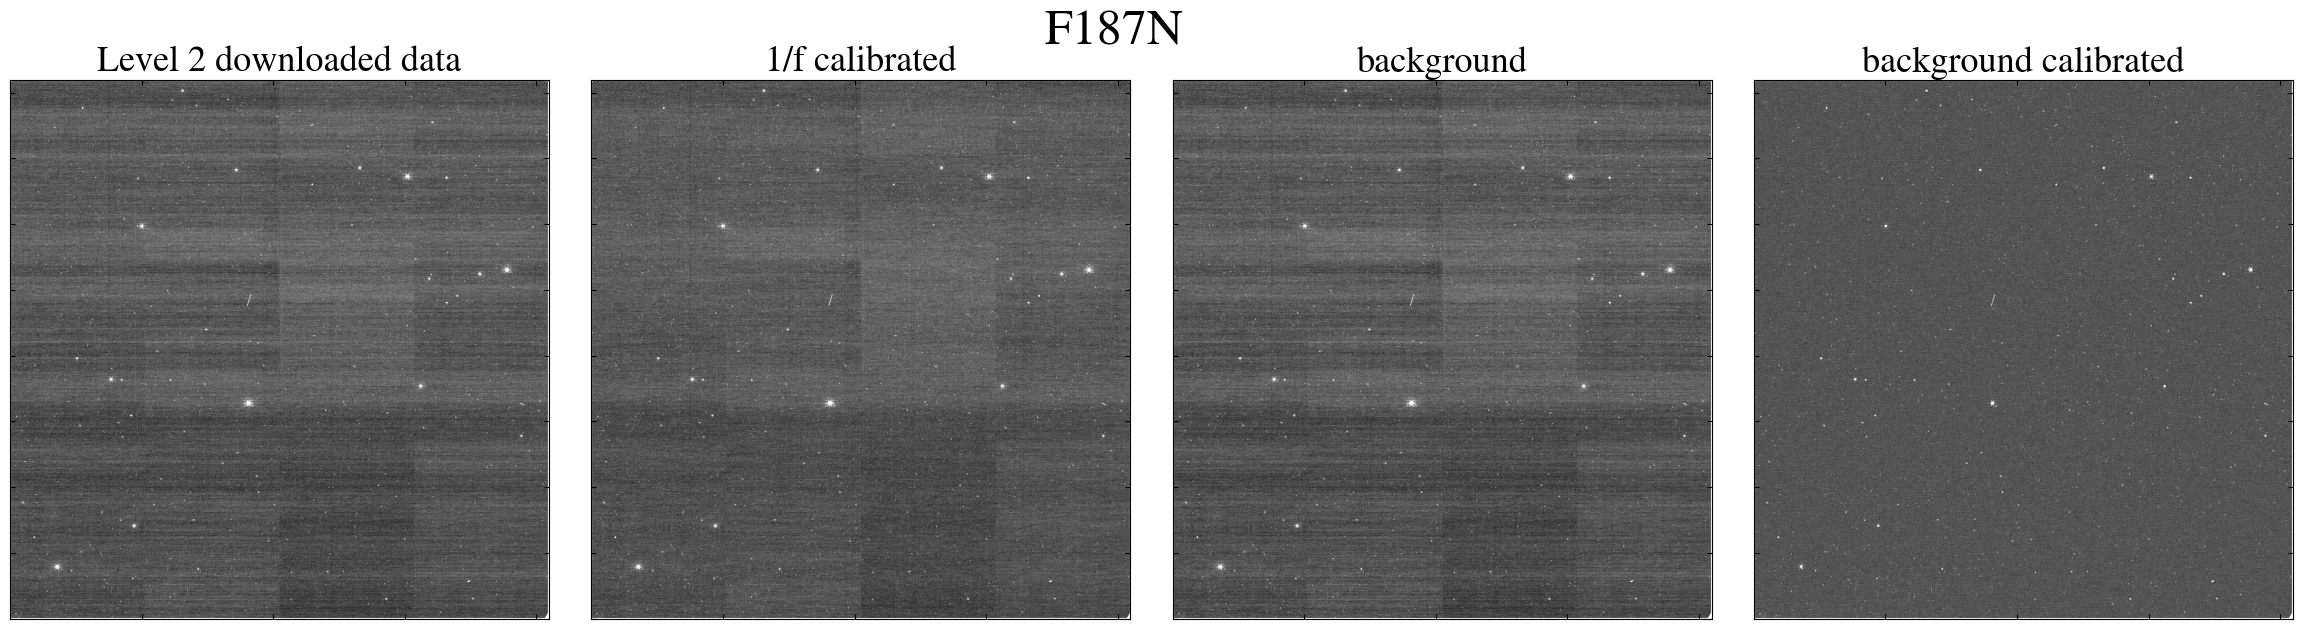

----Pipeline-----
JWST pipeline version             : 2.0.1
Calibration Reference Data System : 13.1.13
CRDS context map                  : jwst_1535.pmap
Read-out pattern                  : BRIGHT2
Number of read-out groups         : 2
----Completed----


In [4]:
JWST_files.run_pipeline_single( IMAGE_INDEX         = 81,
                                detection_sigma     = 2.0,
                                overwrite_always_run= False,
                                save                = True,)


[[ 14.78257831  14.79257831]
 [-72.12083538 -72.11751167]]
Saving in file :  Plots/show_detections/detections_[[ 14.78257831  14.79257831]
 [-72.12083538 -72.11751167]]_bgsub_F115W_Starbug2.pdf


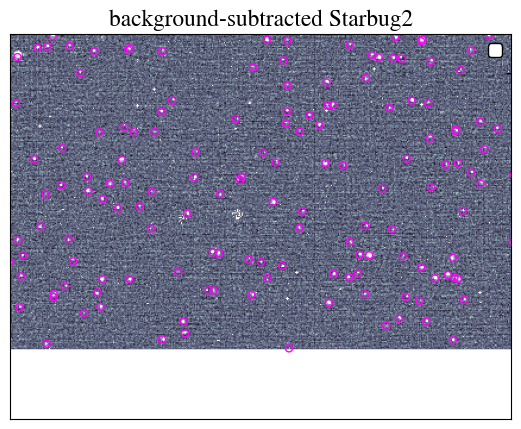

In [8]:
IMAGE_INDEX = 81

RA_min, RA_max      = JWST_files.aperture_data['F115W'].RA.min(), JWST_files.aperture_data['F115W'].RA.max()
DEC_min, DEC_max    = JWST_files.aperture_data['F115W'].DEC.min(), JWST_files.aperture_data['F115W'].DEC.max()
# region              = np.array([[RA_min, RA_max, [DEC_min, DEC_max] ]])
# print(region)
region              = np.array([[14.78257831, 14.79257831], [-72.12083538, -72.117511671] ])
print(region)


catalogue_path  = 'Photometry/NGC346_NIRCam_and_MIRI_Public_JWST_Catalogue.fits'
Catalogue       = phot_tk.Read_Catalogue(catalogue_path = catalogue_path)
Catalogue.mask_region(RA = (RA_min, RA_max ), DEC = (DEC_min, DEC_max))

specific_ra_dec = np.vstack([Catalogue.sub_cat_data['ra'], Catalogue.sub_cat_data['dec']])

JWST_files.show_detections( filters             = ['F115W'],
                            image_type          = 'bgsub',
                            IMAGE_INDEX         = IMAGE_INDEX,
                            draw_own_detections = True,
                            specific_ra_dec     = specific_ra_dec,
                            marker_radius_pixel = 3,
                            save                = True,
                            save_dir            = 'Plots/show_detections',
                            region              = region)#


In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord

sky1 =  JWST_files.world_coord_sources['F115W'] 
sky2 = SkyCoord(Catalogue.sub_cat_data['ra'] * u.deg,
                Catalogue.sub_cat_data['dec'] * u.deg)

A, B, a_idx, b_idx = JWST_files.cross_match_detections(sky1=sky1, sky2=sky2, det_tol=0.5*u.arcsec)

In [ ]:
from tabulate import tabulate


table_data = zip(A[a_idx][:, 0], B[b_idx][:, 0],A[a_idx][:, 1], B[b_idx][:, 1], JWST_files.magnitudes['F115W'][a_idx], Catalogue.sub_cat_data['F115W'][b_idx])

print(tabulate(table_data, headers=['ra own','ra jeroen','dec own','dec jeroen','mag own', 'mag Jeroen'],tablefmt="grid"))


In [ ]:
catalogue_path  = 'Photometry/NGC346_NIRCam_and_MIRI_Public_JWST_Catalogue.fits'
Catalogue       = phot_tk.Read_Catalogue(catalogue_path = catalogue_path)
Catalogue.mask_region(RA = (RA_min, RA_max ), DEC = (DEC_min, DEC_max))


fig = plt.figure()
gs = fig.add_gridspec(1, 1, figure=fig, wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])


filter  = 'F187N'
mask    = Catalogue.sub_cat_data[filter] < 50
samples = Catalogue.sub_cat_data[filter][mask]
N_samples = len(samples)


dx, bin_edges = knuth_bin_width(samples, return_bins=True)
hist = np.histogram(samples, bins=bin_edges)[0]
ax0.stairs(
    hist,
    edges=bin_edges, fill=False, label=f'Catalogue        - {N_samples}', lw=2, edgecolor='black'
    )


own_phot = JWST_files.magnitudes[filter]
N_own_phot = len(own_phot)
own_hist = np.histogram(own_phot, bins=bin_edges)[0]
ax0.stairs(
    own_hist,
    edges=bin_edges, fill=False, label=f'aperture_phot  - {N_own_phot}', lw=2, edgecolor='blue'
    )
    

ax0.legend()
ax0.set_xlabel("Vega Magnitude")
ax0.set_ylabel("Count")
ax0.set_ylim(0, 500)
fig.suptitle(f"Detected sources in {filter} ")
plt.show()